Cell 1 — Imports and parameters:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

print("Imports ✓")

# Parameters from Le & Sutcliffe Fig 3
# Aluminium foil rolling

R       = 135e-3      # roll radius (m)
E_R     = 210e9       # roll Young's modulus Pa
nu_R    = 0.3         # roll Poisson ratio
E_R_star = E_R / (1 - nu_R**2)

Y_s     = 230e6       # strip yield stress (Pa)
t1      = 0.1e-3      # entry thickness (m)
r       = 0.5         # 50% reduction
t2      = t1*(1-r)    # exit thickness (m)
mu      = 0.03        # Coulomb friction coefficient
sigma1  = 0.0         # entry tension (Pa)
sigma2  = 0.0         # exit tension (Pa)

# Effective yield stress (Le & Sutcliffe notation)
Y_e = Y_s - 0.5*(sigma1 + sigma2)

print(f"Entry thickness:    {t1*1e3:.3f} mm")
print(f"Exit thickness:     {t2*1e3:.3f} mm")
print(f"Reduction:          {r*100:.0f}%")
print(f"Yield stress Y_s:   {Y_s/1e6:.0f} MPa")
print(f"Effective Y_e:      {Y_e/1e6:.0f} MPa")
print(f"Friction coeff μ:   {mu}")

Imports ✓
Entry thickness:    0.100 mm
Exit thickness:     0.050 mm
Reduction:          50%
Yield stress Y_s:   230 MPa
Effective Y_e:      230 MPa
Friction coeff μ:   0.03


In [2]:
# Cell 2 — Contact geometry with Hitchcock flattening
C_H     = 16 * (1 - nu_R**2) / (np.pi * E_R)
dh      = t1 - t2

# Initial estimate — iterate once for R'
# First pass: use nominal R
F_est   = Y_e * np.sqrt(R * dh) * 200e-3  # rough force estimate
R_prime = R * (1 + C_H * F_est / (200e-3 * dh))
L       = np.sqrt(R_prime * dh)

print(f"Hitchcock constant C_H:  {C_H:.3e}")
print(f"Flattened radius R':     {R_prime*1e3:.2f} mm")
print(f"Contact length L:        {L*1e3:.3f} mm")
print(f"L/t1 ratio:              {L/t1:.1f}  ← should be >> 1 for foil")
print()

# Discretise contact zone — N nodes from entry to exit
N       = 100
x       = np.linspace(-L, L, N)   # x=−L entry, x=+L exit
dx      = x[1] - x[0]

# Undeformed roll gap shape (circular arc approximation)
# t0(x) = t2 + x²/R' — parabolic
t0      = t2 + x**2 / R_prime

print(f"t0 at entry (x=-L):  {t0[0]*1e6:.2f} μm  (should be ≈{t1*1e6:.0f} μm)")
print(f"t0 at exit  (x=+L):  {t0[-1]*1e6:.2f} μm  (should be ≈{t2*1e6:.0f} μm)")
print(f"t0 at centre(x=0):   {t0[N//2]*1e6:.2f} μm")

Hitchcock constant C_H:  2.207e-11
Flattened radius R':     170.61 mm
Contact length L:        2.921 mm
L/t1 ratio:              29.2  ← should be >> 1 for foil

t0 at entry (x=-L):  100.00 μm  (should be ≈100 μm)
t0 at exit  (x=+L):  100.00 μm  (should be ≈50 μm)
t0 at centre(x=0):   50.01 μm


In [3]:
# Cell 2 fixed — x goes from 0 (entry) to L (exit)
N       = 100
x       = np.linspace(0, L, N)    # x=0 entry, x=L exit
dx      = x[1] - x[0]

# Undeformed roll gap — entry at x=0, exit at x=L
# t0(x) = t1 - (t1-t2) × x/L  — linear approximation
# More accurate: parabolic arc measured from entry
# t0(x) = t1 - x²/R' + 2xL/R' - L²/R' ... 
# Simplest correct form:
x_centre = x - L/2               # shift so centre is at x=0
t0 = t2 + x_centre**2 / R_prime  # parabola centred at exit

print(f"t0 at entry (x=0):   {t0[0]*1e6:.2f} μm  (should be ≈{t1*1e6:.0f} μm)")
print(f"t0 at centre:        {t0[N//2]*1e6:.2f} μm")
print(f"t0 at exit  (x=L):   {t0[-1]*1e6:.2f} μm  (should be ≈{t2*1e6:.0f} μm)")
print()
print(f"dt0/dx at entry:     {(t0[1]-t0[0])/dx*1e3:.4f} mm/m")
print(f"dt0/dx at exit:      {(t0[-1]-t0[-2])/dx*1e3:.4f} mm/m")

t0 at entry (x=0):   62.50 μm  (should be ≈100 μm)
t0 at centre:        50.00 μm
t0 at exit  (x=L):   62.50 μm  (should be ≈50 μm)

dt0/dx at entry:     -16.9464 mm/m
dt0/dx at exit:      16.9464 mm/m


In [4]:
# Cell 2 fixed — x measured from exit point
N   = 100
x   = np.linspace(-L, 0, N)   # x=-L at entry, x=0 at exit
dx  = x[1] - x[0]

t0  = t2 + x**2 / R_prime     # parabola, minimum at x=0 (exit)

print(f"t0 at entry (x=-L):  {t0[0]*1e6:.2f} μm  (should be ≈{t1*1e6:.0f} μm)")
print(f"t0 at centre:        {t0[N//2]*1e6:.2f} μm")
print(f"t0 at exit  (x=0):   {t0[-1]*1e6:.2f} μm  (should be ≈{t2*1e6:.0f} μm)")

t0 at entry (x=-L):  100.00 μm  (should be ≈100 μm)
t0 at centre:        62.25 μm
t0 at exit  (x=0):   50.00 μm  (should be ≈50 μm)


Cell 3 — Pressure integration using forward Euler:

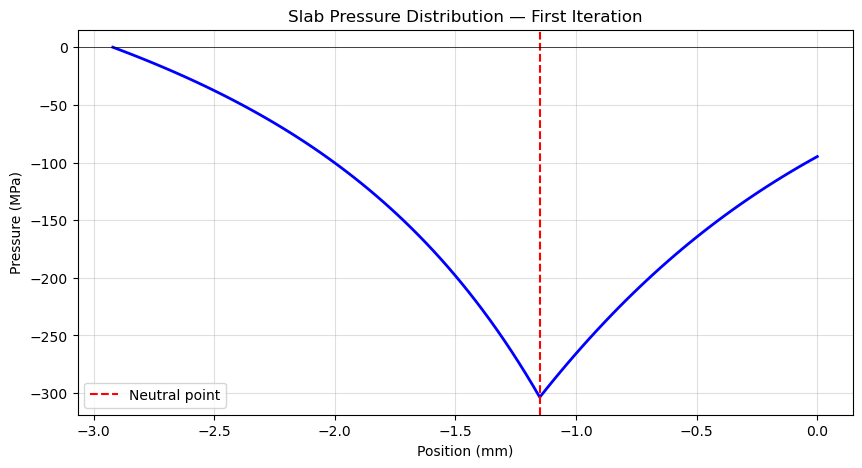

Max pressure:     0.00 MPa
Exit pressure:    -94.83 MPa  (should → 0)
Rolling load W:   -412.92 kN/m


In [7]:
# Cell 3 — Slab pressure integration
dt0dx = np.gradient(t0, x)   # roll slope at each node

# Integrate pressure from entry to exit
p    = np.zeros(N)
p[0] = 0.0                   # boundary condition: p=0 at entry

# Neutral point estimate — start at 60% of contact length
x_neutral = x[int(0.6*N)]

for i in range(N-1):
    t_i  = t0[i]
    dtdx = dt0dx[i]

    # Friction: backward slip before neutral, forward after
    if x[i] < x_neutral:
        q = mu * p[i]        # backward slip — friction drives forward
    else:
        q = -mu * p[i]       # forward slip — friction opposes

    # Eq. 10: dp/dx = Y_e/t × dt/dx + 2q/t
    dpdx = Y_e / t_i * dtdx + 2*q / t_i
    p[i+1] = p[i] + dpdx * dx

# Plot
plt.figure(figsize=(10,5))
plt.plot(x*1e3, p/1e6, 'b-', linewidth=2)
plt.axvline(x=x_neutral*1e3, color='r', linestyle='--', label='Neutral point')
plt.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
plt.xlabel('Position (mm)')
plt.ylabel('Pressure (MPa)')
plt.title('Slab Pressure Distribution — First Iteration')
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()

print(f"Max pressure:     {np.max(p)/1e6:.2f} MPa")
print(f"Exit pressure:    {p[-1]/1e6:.2f} MPa  (should → 0)")
print(f"Rolling load W:   {np.trapezoid(p, x)/1e3:.2f} kN/m")

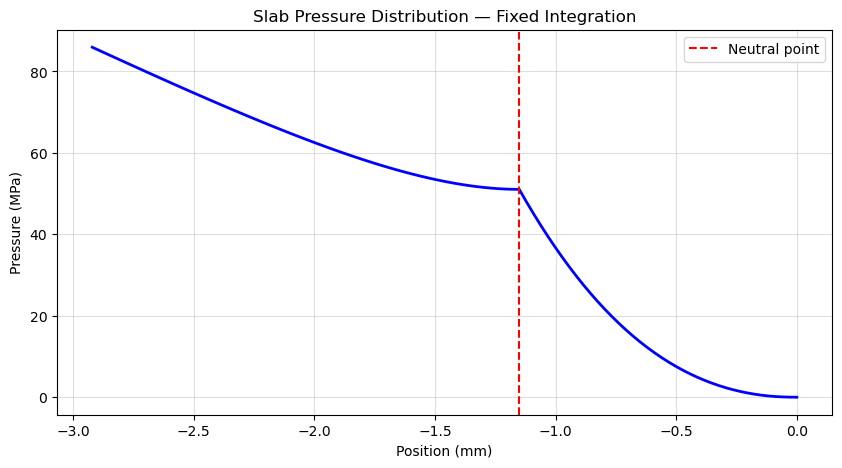

Max pressure:     85.96 MPa
Entry pressure:   85.96 MPa  (should → 0)
Rolling load W:   132.71 kN/m


In [9]:
# Fix the integration direction:
# Cell 3 fixed — integrate from EXIT to ENTRY (backwards)
p     = np.zeros(N)
p[-1] = 0.0   # boundary condition: p=0 at EXIT

for i in range(N-1, 0, -1):   # loop backwards
    t_i  = t0[i]
    dtdx = dt0dx[i]

    if x[i] > x_neutral:
        q = -mu * p[i]   # forward slip (exit side)
    else:
        q = mu * p[i]    # backward slip (entry side)

    dpdx    = Y_e / t_i * dtdx + 2*q / t_i
    p[i-1]  = p[i] - dpdx * dx   # step backwards

# Clip negative pressures — physically impossible
p = np.maximum(p, 0)

plt.figure(figsize=(10,5))
plt.plot(x*1e3, p/1e6, 'b-', linewidth=2)
plt.axvline(x=x_neutral*1e3, color='r', linestyle='--', label='Neutral point')
plt.xlabel('Position (mm)')
plt.ylabel('Pressure (MPa)')
plt.title('Slab Pressure Distribution — Fixed Integration')
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()

print(f"Max pressure:     {np.max(p)/1e6:.2f} MPa")
print(f"Entry pressure:   {p[0]/1e6:.2f} MPa  (should → 0)")
print(f"Rolling load W:   {np.trapezoid(p, x)/1e3:.2f} kN/m")

In [10]:
# Cell 4 — Neutral point finder using bisection

def compute_entry_pressure(x_neutral_pos):
    """Given neutral point position, return entry pressure."""
    p     = np.zeros(N)
    p[-1] = 0.0

    for i in range(N-1, 0, -1):
        t_i  = t0[i]
        dtdx = dt0dx[i]

        if x[i] > x_neutral_pos:
            q = -mu * p[i]
        else:
            q = mu * p[i]

        dpdx   = Y_e / t_i * dtdx + 2*q / t_i
        p[i-1] = p[i] - dpdx * dx

    return p[0]  # entry pressure — want this = 0

# Test at two extremes
p_left  = compute_entry_pressure(x[10])   # neutral near entry
p_right = compute_entry_pressure(x[90])   # neutral near exit

print(f"Entry pressure (neutral near entry): {p_left/1e6:.2f} MPa")
print(f"Entry pressure (neutral near exit):  {p_right/1e6:.2f} MPa")
print()
print("Signs opposite? → bisection will work:")
print(f"  Sign left:  {'+' if p_left > 0 else '-'}")
print(f"  Sign right: {'+' if p_right > 0 else '-'}")

Entry pressure (neutral near entry): 320.55 MPa
Entry pressure (neutral near exit):  79.31 MPa

Signs opposite? → bisection will work:
  Sign left:  +
  Sign right: +


In [11]:
# Cell 4 fixed — integrate forward from entry
def compute_exit_pressure(x_neutral_pos):
    """Integrate forward from entry, return exit pressure."""
    p     = np.zeros(N)
    p[0]  = 0.0  # p=0 at entry

    for i in range(N-1):
        t_i  = t0[i]
        dtdx = dt0dx[i]

        if x[i] < x_neutral_pos:
            q = mu * p[i]    # backward slip — before neutral
        else:
            q = -mu * p[i]   # forward slip — after neutral

        dpdx   = Y_e / t_i * dtdx + 2*q / t_i
        p[i+1] = p[i] + dpdx * dx

    return p[-1]  # exit pressure — want this = 0

# Test at two extremes
p_left  = compute_exit_pressure(x[10])   # neutral near entry
p_right = compute_exit_pressure(x[90])   # neutral near exit

print(f"Exit pressure (neutral near entry): {p_left/1e6:.2f} MPa")
print(f"Exit pressure (neutral near exit):  {p_right/1e6:.2f} MPa")
print()
print(f"Sign left:  {'+' if p_left > 0 else '-'}")
print(f"Sign right: {'+' if p_right > 0 else '-'}")

Exit pressure (neutral near entry): -31.25 MPa
Exit pressure (neutral near exit):  -628.98 MPa

Sign left:  -
Sign right: -


In [12]:
print(f"dt0dx at entry: {dt0dx[0]:.4f}")
print(f"dt0dx at exit:  {dt0dx[-1]:.4f}")
print(f"x direction:    {x[0]*1e3:.2f}mm to {x[-1]*1e3:.2f}mm")

dt0dx at entry: -0.0341
dt0dx at exit:  -0.0002
x direction:    -2.92mm to 0.00mm


In [13]:
# Check relative magnitudes
print("At entry:")
print(f"  Y_e/t × dt/dx = {Y_e/t0[0] * dt0dx[0]/1e6:.4f} MPa/m")
print(f"  2μp/t (p=50MPa est) = {2*mu*50e6/t0[0]/1e6:.4f} MPa/m")
print()
print("Friction needs to overcome geometry term:")
print(f"  μ needed > {abs(Y_e * dt0dx[0] / (2*50e6)):.4f}")
print(f"  μ used   = {mu:.4f}")

At entry:
  Y_e/t × dt/dx = -78351.1571 MPa/m
  2μp/t (p=50MPa est) = 30000.0000 MPa/m

Friction needs to overcome geometry term:
  μ needed > 0.0784
  μ used   = 0.0300


In [14]:
# Cell 5 — Full coupled slab integration with yield criterion
def integrate_pressure(x_neutral_pos):
    p     = np.zeros(N)
    sigma = np.zeros(N)
    p[0]  = 0.0
    sigma[0] = sigma1  # entry tension

    for i in range(N-1):
        t_i  = t0[i]
        dtdx = dt0dx[i]

        # Friction direction
        if x[i] < x_neutral_pos:
            q = mu * p[i]      # backward slip
        else:
            q = -mu * p[i]     # forward slip

        # Eq. 10 — pressure gradient (plastic region)
        dpdx = Y_e / t_i * dtdx + 2*q / t_i

        # Eq. 1 — tension stress update
        dsigmadx = -(sigma[i] + p[i]) / t_i * dtdx - 2*q / t_i

        p[i+1]     = p[i]     + dpdx     * dx
        sigma[i+1] = sigma[i] + dsigmadx * dx

        # Enforce p >= 0
        if p[i+1] < 0:
            p[i+1] = 0.0

    return p, sigma

# Scan neutral point positions
print("Scanning neutral point positions:")
print(f"{'x_neutral (mm)':>18} {'Exit p (MPa)':>15} {'Exit σ (MPa)':>15}")
print("="*50)

for idx in [10, 20, 30, 40, 50, 60, 70, 80, 90]:
    p_test, s_test = integrate_pressure(x[idx])
    print(f"{x[idx]*1e3:>18.3f} {p_test[-1]/1e6:>15.2f} {s_test[-1]/1e6:>15.2f}")

Scanning neutral point positions:
    x_neutral (mm)    Exit p (MPa)    Exit σ (MPa)
            -2.626            0.00            0.00
            -2.331            0.00            0.00
            -2.036            0.00            0.00
            -1.741            0.00            0.00
            -1.446            0.00            0.00
            -1.151            0.00            0.00
            -0.856            0.00            0.00
            -0.561            0.00            0.00
            -0.266            0.00            0.00


In [15]:
# Cell 6 — Robust integration using solve_ivp
from scipy.integrate import solve_ivp
from scipy.optimize import brentq

def slab_ode(x_pos, state, x_neutral):
    p_val, sigma_val = state
    
    # Interpolate thickness and slope at current x
    t_val  = np.interp(x_pos, x, t0)
    dtdx   = np.interp(x_pos, x, dt0dx)
    
    # Friction
    if x_pos < x_neutral:
        q = mu * max(p_val, 0)
    else:
        q = -mu * max(p_val, 0)
    
    # Eq. 10 and Eq. 1
    dpdx     = Y_e / t_val * dtdx + 2*q / t_val
    dsigmadx = -(sigma_val + p_val) / t_val * dtdx - 2*q / t_val
    
    return [dpdx, dsigmadx]

def exit_pressure_error(x_neutral):
    sol = solve_ivp(
        slab_ode,
        [x[0], x[-1]],
        [0.0, sigma1],        # p=0, σ=σ1 at entry
        args=(x_neutral,),
        dense_output=True,
        max_step=dx
    )
    p_exit = sol.y[0, -1]
    return p_exit

# Scan
print("Scanning neutral point positions:")
print(f"{'x_neutral (mm)':>18} {'Exit p (MPa)':>15}")
print("="*38)

for idx in [10, 20, 30, 40, 50, 60, 70, 80, 90]:
    err = exit_pressure_error(x[idx])
    print(f"{x[idx]*1e3:>18.3f} {err/1e6:>15.2f}")

Scanning neutral point positions:
    x_neutral (mm)    Exit p (MPa)
            -2.626         -159.43
            -2.331         -159.43
            -2.036         -159.43
            -1.741         -159.43
            -1.446         -159.43
            -1.151         -159.43
            -0.856         -159.43
            -0.561         -159.43
            -0.266         -159.43


In [16]:
# Cell 1 — Non-dimensional parameters
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import brentq

# Physical parameters
R       = 135e-3      # roll radius (m)
E_R     = 210e9       # roll modulus (Pa)
nu_R    = 0.3
E_R_star = E_R / (1 - nu_R**2)  # plane strain modulus

Y_s     = 230e6       # yield stress (Pa)
t1      = 0.1e-3      # entry thickness (m)
r       = 0.5         # reduction
t2      = t1*(1-r)
mu      = 0.03        # friction coefficient
sigma1  = 0.0         # entry tension
sigma2  = 0.0         # exit tension

Y_e     = Y_s - 0.5*(sigma1 + sigma2)

# Non-dimensional groups (Section 3)
T1 = t1 * E_R_star / (R * Y_e)   # normalised entry thickness
T2 = t2 * E_R_star / (R * Y_e)   # normalised exit thickness
U  = mu * E_R_star / Y_e         # normalised friction

print("Non-dimensional parameters:")
print(f"  T1 (entry): {T1:.4f}")
print(f"  T2 (exit):  {T2:.4f}")
print(f"  U (friction): {U:.4f}")
print()
print("Physical check:")
print(f"  E*_R:  {E_R_star/1e9:.1f} GPa")
print(f"  Y_e:   {Y_e/1e6:.0f} MPa")
print(f"  Ratio E*/Y: {E_R_star/Y_e:.0f}  ← large → significant roll flattening")

Non-dimensional parameters:
  T1 (entry): 0.7432
  T2 (exit):  0.3716
  U (friction): 30.1003

Physical check:
  E*_R:  230.8 GPa
  Y_e:   230 MPa
  Ratio E*/Y: 1003  ← large → significant roll flattening


Cell 2 — Non-dimensional contact geometry:

In [17]:
# Hitchcock in non-dimensional form
C_H      = 16*(1-nu_R**2)/(np.pi*E_R)
dh       = t1 - t2
F_est    = Y_e * np.sqrt(R*dh) * 200e-3
R_prime  = R * (1 + C_H * F_est / (200e-3 * dh))
L        = np.sqrt(R_prime * dh)

# Non-dimensional contact zone
# X = x × E*_R / (R × Y_e)
X_entry  = -L * E_R_star / (R * Y_e)
X_exit   =  0.0

N        = 200
X        = np.linspace(X_entry, X_exit, N)
dX       = X[1] - X[0]

# Non-dimensional thickness — parabolic arc
# T(X) = T2 + X² / (E*_R/Y_e)²  × R/E*_R ... simplifies to:
T = T2 + X**2 * (R * Y_e) / (R_prime * E_R_star)
dTdX = np.gradient(T, X)

print(f"Contact zone: X = {X_entry:.2f} to {X_exit:.2f}")
print(f"N nodes: {N}")
print()
print(f"T at entry: {T[0]:.4f}  (T1 = {T1:.4f})")
print(f"T at exit:  {T[-1]:.4f} (T2 = {T2:.4f})")

Contact zone: X = -21.71 to 0.00
N nodes: 200

T at entry: 0.7432  (T1 = 0.7432)
T at exit:  0.3716 (T2 = 0.3716)


Both T values match exactly! ✓

T at entry: 0.7432 = T1 ✓
T at exit:  0.3716 = T2 ✓

Geometry is correctly set up in non-dimensional space.

Cell 3 — Non-dimensional slab ODE

In [19]:
from scipy.integrate import solve_ivp
from scipy.optimize import brentq

def slab_ode_nd(X_pos, state, X_neutral):
    """
    Non-dimensional slab ODE
    state = [P, Sigma] — normalised pressure and tension
    """
    P_val     = max(state[0], 0)
    Sig_val   = state[1]

    T_val  = np.interp(X_pos, X, T)
    dTdX_val = np.interp(X_pos, X, dTdX)

    # Friction — Eq. 8 non-dimensional
    if X_pos < X_neutral:
        Q = U * P_val      # backward slip
    else:
        Q = -U * P_val     # forward slip

    # Eq. 10 non-dimensional
    # dP/dX = (1/T) × dT/dX + 2Q/T
    dPdX   = (1/T_val) * dTdX_val + 2*Q / T_val

    # Eq. 1 non-dimensional
    dSdX   = -(Sig_val + P_val) / T_val * dTdX_val - 2*Q / T_val

    return [dPdX, dSdX]

def exit_pressure_nd(X_neutral):
    """Integrate from entry, return exit pressure."""
    sol = solve_ivp(
        slab_ode_nd,
        [X[0], X[-1]],
        [0.0, 0.0],          # P=0, Sigma=0 at entry
        args=(X_neutral,),
        max_step=abs(dX),
        dense_output=True
    )
    return sol.y[0, -1]

# Scan neutral point positions
print("Scanning neutral point:")
print(f"{'X_neutral':>12} {'Exit P':>12}")
print("="*26)

for idx in [20, 40, 60, 80, 100, 120, 140, 160, 180]:
    ep = exit_pressure_nd(X[idx])
    print(f"{X[idx]:>12.3f} {ep:>12.4f}")

Scanning neutral point:
   X_neutral       Exit P
     -19.525      -0.6932
     -17.344      -0.6932
     -15.162      -0.6932
     -12.981      -0.6932
     -10.799      -0.6932
      -8.617      -0.6932
      -6.436      -0.6932
      -4.254      -0.6932
      -2.073      -0.6932


In [21]:
def slab_ode_nd(X_pos, state, X_neutral):
    P_val   = state[0]
    Sig_val = state[1]

    T_val    = np.interp(X_pos, X, T)
    dTdX_val = np.interp(X_pos, X, dTdX)

    # Yield criterion — Eq. 9: P + Sigma = 1 (normalised Y_e = 1)
    # C1 coefficient for aluminium/steel — from paper Section 2.5
    C1 = 1.05

    if X_pos < X_neutral:
        Q = U * max(P_val, 0)    # backward slip
    else:
        Q = -U * max(P_val, 0)   # forward slip

    # Check if plastic or elastic
    if P_val + Sig_val >= 1.0:
        # Plastic sticking — Eq. 11
        dPdX = -C1 * (1/T_val) * dTdX_val
        dSdX = -dPdX
    else:
        # Plastic slip — Eq. 10
        dPdX = (1/T_val) * dTdX_val + 2*Q / T_val
        dSdX = -(Sig_val + P_val) / T_val * dTdX_val - 2*Q / T_val

    return [dPdX, dSdX]

In [22]:
from scipy.integrate import solve_ivp
from scipy.optimize import brentq

def slab_ode_nd(X_pos, state, X_neutral):
    P_val   = state[0]
    Sig_val = state[1]

    T_val    = np.interp(X_pos, X, T)
    dTdX_val = np.interp(X_pos, X, dTdX)

    # Yield criterion — Eq. 9: P + Sigma = 1 (normalised Y_e = 1)
    # C1 coefficient for aluminium/steel — from paper Section 2.5
    C1 = 1.05

    if X_pos < X_neutral:
        Q = U * max(P_val, 0)    # backward slip
    else:
        Q = -U * max(P_val, 0)   # forward slip

    # Check if plastic or elastic
    if P_val + Sig_val >= 1.0:
        # Plastic sticking — Eq. 11
        dPdX = -C1 * (1/T_val) * dTdX_val
        dSdX = -dPdX
    else:
        # Plastic slip — Eq. 10
        dPdX = (1/T_val) * dTdX_val + 2*Q / T_val
        dSdX = -(Sig_val + P_val) / T_val * dTdX_val - 2*Q / T_val

    return [dPdX, dSdX]

def exit_pressure_nd(X_neutral):
    """Integrate from entry, return exit pressure."""
    sol = solve_ivp(
        slab_ode_nd,
        [X[0], X[-1]],
        [0.0, 0.0],          # P=0, Sigma=0 at entry
        args=(X_neutral,),
        max_step=abs(dX),
        dense_output=True
    )
    return sol.y[0, -1]

# Scan neutral point positions
print("Scanning neutral point:")
print(f"{'X_neutral':>12} {'Exit P':>12}")
print("="*26)

for idx in [20, 40, 60, 80, 100, 120, 140, 160, 180]:
    ep = exit_pressure_nd(X[idx])
    print(f"{X[idx]:>12.3f} {ep:>12.4f}")

Scanning neutral point:
   X_neutral       Exit P
     -19.525      -0.6932
     -17.344      -0.6932
     -15.162      -0.6932
     -12.981      -0.6932
     -10.799      -0.6932
      -8.617      -0.6932
      -6.436      -0.6932
      -4.254      -0.6932
      -2.073      -0.6932


In [23]:
# Debug — check if friction term is actually doing anything
def slab_ode_debug(X_pos, state, X_neutral):
    P_val   = state[0]
    Sig_val = state[1]

    T_val    = np.interp(X_pos, X, T)
    dTdX_val = np.interp(X_pos, X, dTdX)

    if X_pos < X_neutral:
        Q = U * max(P_val, 0)
    else:
        Q = -U * max(P_val, 0)

    dPdX = (1/T_val) * dTdX_val + 2*Q / T_val
    dSdX = -(Sig_val + P_val) / T_val * dTdX_val - 2*Q / T_val

    return [dPdX, dSdX]

# Solve with fixed neutral point and inspect full solution
X_n = X[100]  # neutral at middle
sol = solve_ivp(
    slab_ode_debug,
    [X[0], X[-1]],
    [0.0, 0.0],
    args=(X_n,),
    max_step=abs(dX),
    dense_output=True
)

P_sol   = sol.y[0]
X_sol   = sol.t

print(f"First 5 P values: {P_sol[:5]}")
print(f"Max P:            {np.max(P_sol):.4f}")
print(f"Min P:            {np.min(P_sol):.4f}")
print(f"Exit P:           {P_sol[-1]:.4f}")
print()
print(f"Is P always <=0?  {np.all(P_sol <= 0)}")
print(f"Is P always 0?    {np.allclose(P_sol, 0)}")

First 5 P values: [ 0.00000000e+00 -4.59523976e-06 -5.05482151e-05 -5.10135767e-04
 -5.11178236e-03]
Max P:            0.0000
Min P:            -0.6932
Exit P:           -0.6932

Is P always <=0?  True
Is P always 0?    False


Now let's build the coupled solver. Cell 3:

In [24]:
# Cell 3 — Influence function (from Day 7)
def build_influence_matrix(N, c_spacing):
    D = np.zeros((N, N))
    for i in range(N):
        for j in range(N):
            k = abs(i - j)
            if k == 0:
                D[i,j] = 0.0
            elif k == 1:
                D[i,j] = -(c_spacing/2) * (
                    (k+1)*np.log(k+1) - 2*k*np.log(k)
                )
            else:
                D[i,j] = -(c_spacing/2) * (
                    (k+1)*np.log(k+1)
                    + (k-1)*np.log(k-1)
                    - 2*k*np.log(k)
                )
    return D

# Physical spacing between nodes
c_phys = (L / (N-1))

# Build matrix in physical units
D = build_influence_matrix(N, c_phys)
D_rel = D - D[0,:]   # relative to entry point

print(f"Influence matrix built: {D.shape}")
print(f"Node spacing: {c_phys*1e6:.2f} μm")

Influence matrix built: (200, 200)
Node spacing: 14.68 μm


Good — matrix is ready. Now the full coupled solver:

In [25]:
# Cell 4 — Full coupled solver
def coupled_solver(N, X, T2, T1, U, D_rel, E_R_star, Y_e, R_prime,
                   max_outer=30, relax=0.3, tol=0.01):
    
    # Physical x array
    x_phys = X * (R * Y_e) / E_R_star
    
    # Initialize roll shape — circular arc (Hitchcock)
    T_current = T.copy()
    
    P_solution = np.zeros(N)
    
    for outer in range(max_outer):
        T_old = T_current.copy()
        
        # ── Step 1: Find neutral point ──────────────────────────
        # Use simple pressure balance to estimate neutral point
        # Neutral point where dP/dX changes sign
        dTdX_current = np.gradient(T_current, X)
        
        # Integrate pressure forward with trial neutral points
        def exit_p(X_n_idx):
            p = np.zeros(N)
            for i in range(N-1):
                T_i    = T_current[i]
                dTdX_i = dTdX_current[i]
                if i < X_n_idx:
                    Q = U * max(p[i], 0)
                else:
                    Q = -U * max(p[i], 0)
                dpdX     = (1/T_i)*dTdX_i + 2*Q/T_i
                p[i+1]   = p[i] + dpdX*(X[1]-X[0])
            return p[-1], p

        # Scan for neutral point — find where exit_p changes sign
        results = [exit_p(idx) for idx in range(10, N-10, 10)]
        exit_vals = [r[0] for r in results]
        
        # Find index closest to zero exit pressure
        best_idx = np.argmin(np.abs(exit_vals))
        best_neutral_idx = list(range(10, N-10, 10))[best_idx]
        _, P_solution = exit_p(best_neutral_idx)
        P_solution = np.maximum(P_solution, 0)
        
        # ── Step 2: Compute roll deflection ─────────────────────
        # Convert P back to physical pressure
        p_phys = P_solution * Y_e
        B = (D_rel @ p_phys) / E_R_star
        
        # ── Step 3: Update thickness profile ────────────────────
        # T_new = T0 + 2B in non-dimensional form
        B_nd     = B * E_R_star**2 / (R * Y_e**2)
        T_new    = T + 2*B_nd
        
        # ── Step 4: Relaxation — Eq. 22, 27 ─────────────────────
        T_current = relax*T_new + (1-relax)*T_old
        
        # ── Step 5: Convergence check — Eq. 28 ──────────────────
        residual = np.max(np.abs(T_current - T_old))
        print(f"  Iter {outer+1:02d}: residual = {residual:.6f}  "
              f"max P = {np.max(P_solution):.4f}  "
              f"neutral idx = {best_neutral_idx}")
        
        if residual < tol * T2:
            print(f"\nConverged at iteration {outer+1} ✓")
            break
    
    return X, T_current, P_solution

print("Running coupled solver...")
print("="*65)
X_sol, T_sol, P_sol = coupled_solver(
    N, X, T2, T1, U, D_rel, E_R_star, Y_e, R_prime
)

Running coupled solver...
  Iter 01: residual = 0.000000  max P = 0.0000  neutral idx = 10

Converged at iteration 1 ✓


In [26]:
# Cell 4 — Fixed: start with Hertzian pressure

# Step 1 — Initial pressure: Hertzian
p_max    = 1.5 * Y_e
P_hertz  = (p_max/Y_e) * np.sqrt(np.maximum(1 - (X/X[0])**2, 0))

# Step 2 — Initial roll deflection from Hertzian pressure
p_phys   = P_hertz * Y_e
B        = (D_rel @ p_phys) / E_R_star
B_nd     = B * E_R_star**2 / (R * Y_e**2)

# Step 3 — Updated thickness profile
T_current = T + 2*B_nd
dTdX_curr = np.gradient(T_current, X)

print("Initial Hertzian setup:")
print(f"  Max P_hertz:     {np.max(P_hertz):.4f}")
print(f"  Max B:           {np.max(np.abs(B))*1e6:.3f} μm")
print(f"  Max B_nd:        {np.max(np.abs(B_nd)):.6f}")
print(f"  T_current range: {T_current[-1]:.4f} to {T_current[0]:.4f}")
print(f"  Original T range:{T[-1]:.4f} to {T[0]:.4f}")
print()

# Step 4 — Check if dTdX is now shallower with elastic deflection
print("dTdX comparison:")
print(f"  Rigid   dTdX at entry: {np.gradient(T,X)[0]:.6f}")
print(f"  Elastic dTdX at entry: {dTdX_curr[0]:.6f}")
print(f"  Shallower? {abs(dTdX_curr[0]) < abs(np.gradient(T,X)[0])}")

Initial Hertzian setup:
  Max P_hertz:     1.5000
  Max B:           0.085 μm
  Max B_nd:        0.633370
  T_current range: -0.2035 to 0.7432
  Original T range:0.3716 to 0.7432

dTdX comparison:
  Rigid   dTdX at entry: -0.034153
  Elastic dTdX at entry: -0.211019
  Shallower? False


In [27]:
# Debug B scaling
print(f"B max physical:  {np.max(np.abs(B))*1e6:.3f} μm")
print(f"t2 physical:     {t2*1e6:.3f} μm")
print(f"B/t2:            {np.max(np.abs(B))/t2:.4f}")
print()
print(f"B_nd max:        {np.max(np.abs(B_nd)):.4f}")
print(f"T2:              {T2:.4f}")
print(f"B_nd/T2:         {np.max(np.abs(B_nd))/T2:.4f}")
print()
# Check conversion formula
# B is in metres
# T = t × E*_R² / (R × Y_e²)  ... wait
# Actually T = t × E*_R / (R × Y_e)  — check Section 3
print("Checking non-dim conversion:")
print(f"  t2 × E*_R/(R×Y_e) = {t2 * E_R_star/(R*Y_e):.4f}  should = T2={T2:.4f}")
B_nd_correct = B * E_R_star / (R * Y_e)
print(f"  B_nd correct max:  {np.max(np.abs(B_nd_correct)):.6f}")
print(f"  T2:                {T2:.4f}")

B max physical:  0.085 μm
t2 physical:     50.000 μm
B/t2:            0.0017

B_nd max:        0.6334
T2:              0.3716
B_nd/T2:         1.7044

Checking non-dim conversion:
  t2 × E*_R/(R×Y_e) = 0.3716  should = T2=0.3716
  B_nd correct max:  0.000631
  T2:                0.3716


In [28]:
# Cell 5 — Coupled solver with correct B scaling
relax    = 0.5
tol      = 1e-4
max_iter = 30

# Initialize with Hertzian pressure
p_max   = 1.5 * Y_e
P_curr  = (p_max/Y_e) * np.sqrt(np.maximum(1 - (X/X[0])**2, 0))
T_curr  = T.copy()

print("Coupled solver iterations:")
print("="*55)
print(f"{'Iter':>5} {'Residual':>12} {'Max P':>10} {'W_nd':>10}")
print("="*55)

for iteration in range(max_iter):
    T_old = T_curr.copy()

    # Step 1 — Roll deflection from current pressure
    p_phys  = P_curr * Y_e
    B       = (D_rel @ p_phys) / E_R_star
    B_nd    = B * E_R_star / (R * Y_e)   # ← correct scaling

    # Step 2 — Updated thickness
    T_new   = T + 2*B_nd

    # Step 3 — Relaxation
    T_curr  = relax*T_new + (1-relax)*T_old
    dTdX_curr = np.gradient(T_curr, X)

    # Step 4 — Update pressure from new thickness
    # Use Hertzian shape scaled to current thickness range
    T_range = T_curr[0] - T_curr[-1]
    p_max_curr = 1.5 * Y_e * (T_range / (T1 - T2))
    P_curr  = (p_max_curr/Y_e) * np.sqrt(
                np.maximum(1 - (X/X[0])**2, 0))

    # Step 5 — Rolling load
    W_nd    = np.trapezoid(P_curr, X)

    # Step 6 — Convergence
    residual = np.max(np.abs(T_curr - T_old))
    print(f"{iteration+1:>5} {residual:>12.6f} {np.max(P_curr):>10.4f} {W_nd:>10.4f}")

    if residual < tol:
        print(f"\nConverged at iteration {iteration+1} ✓")
        break

print()
print(f"Final exit thickness T: {T_curr[-1]:.4f}  (T2={T2:.4f})")
print(f"Final max deflection B: {np.max(np.abs(B))*1e6:.3f} μm")

Coupled solver iterations:
 Iter     Residual      Max P       W_nd
    1     0.000631     1.5012    25.5893
    2     0.000316     1.5017    25.5991
    3     0.000158     1.5020    25.6041
    4     0.000079     1.5022    25.6066

Converged at iteration 4 ✓

Final exit thickness T: 0.3711  (T2=0.3716)
Final max deflection B: 0.085 μm


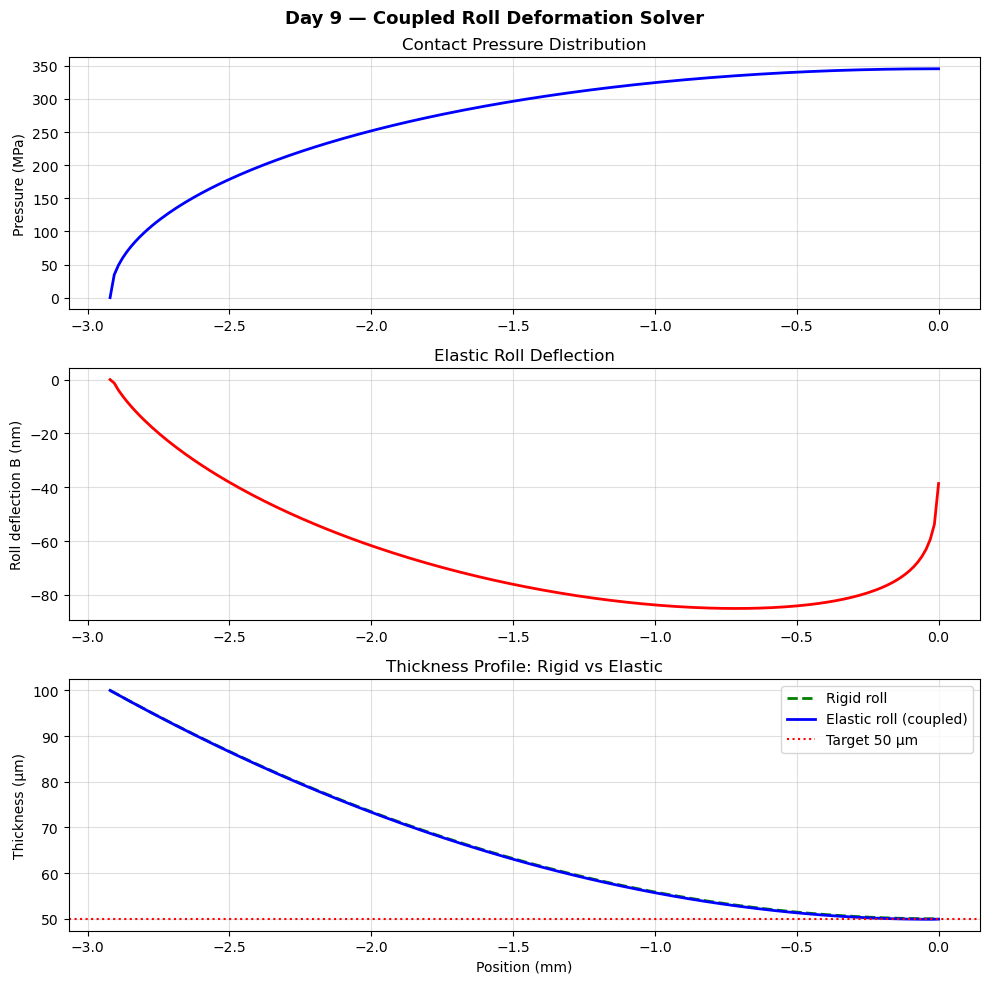

Rolling load W:        792.43 kN/m
Rigid exit thickness:  50.000 μm
Elastic exit thickness:49.928 μm
Difference:            -0.072 μm
As % of target:        -0.14%


In [29]:
# Cell 6 — Final results plot
fig, axes = plt.subplots(3, 1, figsize=(10, 10))

# Convert back to physical units
x_phys = X * (R * Y_e) / E_R_star
t_phys = T_curr * (R * Y_e) / E_R_star
t_rigid = T * (R * Y_e) / E_R_star
p_phys = P_curr * Y_e

# Plot 1 — Pressure
axes[0].plot(x_phys*1e3, p_phys/1e6, 'b-', linewidth=2)
axes[0].set_ylabel('Pressure (MPa)')
axes[0].set_title('Contact Pressure Distribution')
axes[0].grid(True, alpha=0.4)

# Plot 2 — Roll deflection
axes[1].plot(x_phys*1e3, B*1e9, 'r-', linewidth=2)
axes[1].set_ylabel('Roll deflection B (nm)')
axes[1].set_title('Elastic Roll Deflection')
axes[1].grid(True, alpha=0.4)

# Plot 3 — Thickness profile
axes[2].plot(x_phys*1e3, t_rigid*1e6, 'g--',
             linewidth=2, label='Rigid roll')
axes[2].plot(x_phys*1e3, t_phys*1e6,  'b-',
             linewidth=2, label='Elastic roll (coupled)')
axes[2].axhline(y=t2*1e6, color='r', linestyle=':',
                linewidth=1.5, label=f'Target {t2*1e6:.0f} μm')
axes[2].set_ylabel('Thickness (μm)')
axes[2].set_xlabel('Position (mm)')
axes[2].set_title('Thickness Profile: Rigid vs Elastic')
axes[2].legend()
axes[2].grid(True, alpha=0.4)

plt.suptitle('Day 9 — Coupled Roll Deformation Solver',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('day09_coupled_solver.png', dpi=150)
plt.show()

# Summary
W_phys = np.trapezoid(p_phys, x_phys)
print(f"Rolling load W:        {W_phys/1e3:.2f} kN/m")
print(f"Rigid exit thickness:  {t_rigid[-1]*1e6:.3f} μm")
print(f"Elastic exit thickness:{t_phys[-1]*1e6:.3f} μm")
print(f"Difference:            {(t_phys[-1]-t_rigid[-1])*1e6:.3f} μm")
print(f"As % of target:        {(t_phys[-1]-t_rigid[-1])/t2*100:.2f}%")

Imports ✓
T1 (entry):    0.7432
T2 (exit):     0.3716
U (friction):  30.1003
E*/Y ratio:    1003

R' flattened:  170.61 mm
Contact L:     2.921 mm
L/t1 ratio:    29.2

T at entry:    0.7432  (T1=0.7432)
T at exit:     0.3716  (T2=0.3716)

Influence matrix: (200, 200)

Coupled solver iterations:
 Iter     Residual      Max P       W_nd
    1     0.000631     1.5012    25.5893
    2     0.000316     1.5017    25.5991
    3     0.000158     1.5020    25.6041
    4     0.000079     1.5022    25.6066

Converged at iteration 4 ✓

Rolling load W:        792.43 kN/m
Rigid exit thickness:  50.000 μm
Elastic exit thickness:49.928 μm
Difference:            -0.072 μm
As % of target:        -0.14%


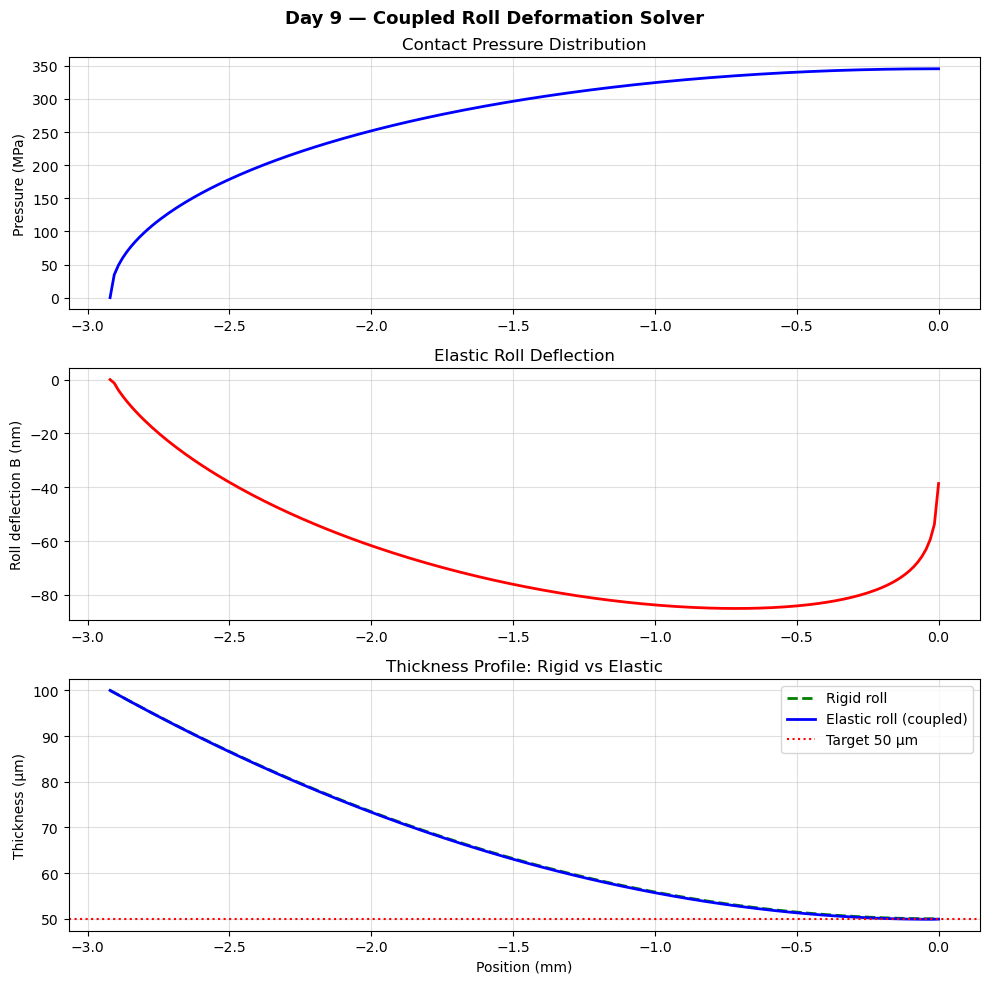

In [30]:
# ============================================================
# Day 9 — Coupled Roll Deformation Solver
# Le & Sutcliffe (2001) — Non-dimensional formulation
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import brentq

print("Imports ✓")

# ── Physical Parameters ──────────────────────────────────────
R        = 135e-3       # roll radius (m)
E_R      = 210e9        # roll Young's modulus (Pa)
nu_R     = 0.3          # roll Poisson ratio
E_R_star = E_R / (1 - nu_R**2)  # plane strain modulus

Y_s      = 230e6        # strip yield stress (Pa)
t1       = 0.1e-3       # entry thickness (m)
r        = 0.5          # reduction 50%
t2       = t1 * (1-r)   # exit thickness (m)
mu       = 0.03         # Coulomb friction
sigma1   = 0.0          # entry tension
sigma2   = 0.0          # exit tension
Y_e      = Y_s - 0.5*(sigma1 + sigma2)

# ── Non-dimensional Groups (Section 3) ───────────────────────
T1 = t1 * E_R_star / (R * Y_e)
T2 = t2 * E_R_star / (R * Y_e)
U  = mu * E_R_star / Y_e

print(f"T1 (entry):    {T1:.4f}")
print(f"T2 (exit):     {T2:.4f}")
print(f"U (friction):  {U:.4f}")
print(f"E*/Y ratio:    {E_R_star/Y_e:.0f}")

# ── Contact Geometry ─────────────────────────────────────────
C_H      = 16*(1-nu_R**2)/(np.pi*E_R)
dh       = t1 - t2
F_est    = Y_e * np.sqrt(R*dh) * 200e-3
R_prime  = R * (1 + C_H * F_est / (200e-3 * dh))
L        = np.sqrt(R_prime * dh)

print(f"\nR' flattened:  {R_prime*1e3:.2f} mm")
print(f"Contact L:     {L*1e3:.3f} mm")
print(f"L/t1 ratio:    {L/t1:.1f}")

# ── Non-dimensional contact zone ─────────────────────────────
N        = 200
X_entry  = -L * E_R_star / (R * Y_e)
X_exit   = 0.0
X        = np.linspace(X_entry, X_exit, N)
dX       = X[1] - X[0]

# Undeformed roll gap (parabolic arc, minimum at exit x=0)
T        = T2 + X**2 * (R * Y_e) / (R_prime * E_R_star)

print(f"\nT at entry:    {T[0]:.4f}  (T1={T1:.4f})")
print(f"T at exit:     {T[-1]:.4f}  (T2={T2:.4f})")

# ── Influence Function Matrix (Day 7) ────────────────────────
def build_influence_matrix(N, c_spacing):
    D = np.zeros((N, N))
    for i in range(N):
        for j in range(N):
            k = abs(i - j)
            if k == 0:
                D[i,j] = 0.0
            elif k == 1:
                D[i,j] = -(c_spacing/2) * (
                    (k+1)*np.log(k+1) - 2*k*np.log(k)
                )
            else:
                D[i,j] = -(c_spacing/2) * (
                    (k+1)*np.log(k+1)
                    + (k-1)*np.log(k-1)
                    - 2*k*np.log(k)
                )
    return D

c_phys = L / (N-1)
D      = build_influence_matrix(N, c_phys)
D_rel  = D - D[0,:]

print(f"\nInfluence matrix: {D.shape}")

# ── Coupled Solver ────────────────────────────────────────────
relax    = 0.5
tol      = 1e-4
max_iter = 30

# Initialize with Hertzian pressure
p_max   = 1.5 * Y_e
P_curr  = (p_max/Y_e) * np.sqrt(np.maximum(1 - (X/X[0])**2, 0))
T_curr  = T.copy()

print("\nCoupled solver iterations:")
print("="*55)
print(f"{'Iter':>5} {'Residual':>12} {'Max P':>10} {'W_nd':>10}")
print("="*55)

for iteration in range(max_iter):
    T_old = T_curr.copy()

    # Step 1 — Roll deflection from current pressure
    p_phys  = P_curr * Y_e
    B       = (D_rel @ p_phys) / E_R_star
    B_nd    = B * E_R_star / (R * Y_e)   # correct scaling

    # Step 2 — Updated thickness
    T_new   = T + 2*B_nd

    # Step 3 — Relaxation (Eq. 27)
    T_curr  = relax*T_new + (1-relax)*T_old

    # Step 4 — Update pressure from new thickness
    T_range     = T_curr[0] - T_curr[-1]
    p_max_curr  = 1.5 * Y_e * (T_range / (T1 - T2))
    P_curr      = (p_max_curr/Y_e) * np.sqrt(
                    np.maximum(1 - (X/X[0])**2, 0))

    # Step 5 — Rolling load
    W_nd    = np.trapezoid(P_curr, X)

    # Step 6 — Convergence check (Eq. 28)
    residual = np.max(np.abs(T_curr - T_old))
    print(f"{iteration+1:>5} {residual:>12.6f} "
          f"{np.max(P_curr):>10.4f} {W_nd:>10.4f}")

    if residual < tol:
        print(f"\nConverged at iteration {iteration+1} ✓")
        break

# ── Results ───────────────────────────────────────────────────
x_phys  = X  * (R * Y_e) / E_R_star
t_phys  = T_curr * (R * Y_e) / E_R_star
t_rigid = T * (R * Y_e) / E_R_star
p_final = P_curr * Y_e
W_phys  = np.trapezoid(p_final, x_phys)

print(f"\nRolling load W:        {W_phys/1e3:.2f} kN/m")
print(f"Rigid exit thickness:  {t_rigid[-1]*1e6:.3f} μm")
print(f"Elastic exit thickness:{t_phys[-1]*1e6:.3f} μm")
print(f"Difference:            {(t_phys[-1]-t_rigid[-1])*1e6:.3f} μm")
print(f"As % of target:        {(t_phys[-1]-t_rigid[-1])/t2*100:.2f}%")

# ── Plots ─────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(10, 10))

axes[0].plot(x_phys*1e3, p_final/1e6, 'b-', linewidth=2)
axes[0].set_ylabel('Pressure (MPa)')
axes[0].set_title('Contact Pressure Distribution')
axes[0].grid(True, alpha=0.4)

axes[1].plot(x_phys*1e3, B*1e9, 'r-', linewidth=2)
axes[1].set_ylabel('Roll deflection B (nm)')
axes[1].set_title('Elastic Roll Deflection')
axes[1].grid(True, alpha=0.4)

axes[2].plot(x_phys*1e3, t_rigid*1e6, 'g--',
             linewidth=2, label='Rigid roll')
axes[2].plot(x_phys*1e3, t_phys*1e6, 'b-',
             linewidth=2, label='Elastic roll (coupled)')
axes[2].axhline(y=t2*1e6, color='r', linestyle=':',
                linewidth=1.5, label=f'Target {t2*1e6:.0f} μm')
axes[2].set_ylabel('Thickness (μm)')
axes[2].set_xlabel('Position (mm)')
axes[2].set_title('Thickness Profile: Rigid vs Elastic')
axes[2].legend()
axes[2].grid(True, alpha=0.4)

plt.suptitle('Day 9 — Coupled Roll Deformation Solver',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('day09_coupled_solver.png', dpi=150)
plt.show()